SVR - Support Vector Regression

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [40]:
dataset = pd.read_csv('Machine-Learning-A-Z-Codes-Datasets/Part 2 - Regression/Section 7 - Support Vector Regression (SVR)/Python/Position_Salaries.csv')

X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [41]:
dataset

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [42]:
print(X)
print(y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [43]:
# we must reshape y to 2d array

y = y.reshape(len(y), 1)
print(y)

[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


In [44]:
# we don't have split to train and test, bc dataset is too small

# we must have feature scaling here on both the level and salary
# normally we do feature scalling after train test split


from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X = sc_X.fit_transform(X)

sc_y = StandardScaler()
y = sc_y.fit_transform(y)
y = y.ravel()

In [45]:
print(X)
print(y)

[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]
[-0.72004253 -0.70243757 -0.66722767 -0.59680786 -0.49117815 -0.35033854
 -0.17428902  0.17781001  0.88200808  2.64250325]


In [46]:
# Training SVR model
from sklearn.svm import SVR
model = SVR(kernel='rbf') # tu trzeba zaznaczyc czy linear kernel czy non-linear kernel

model.fit(X, y)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [47]:
sc_y.inverse_transform(model.predict(sc_X.transform([[6.5]])).reshape(-1, 1))


array([[170370.0204065]])

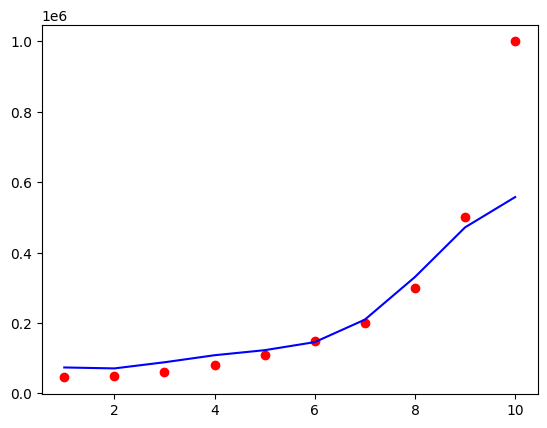

In [50]:
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y.reshape(-1, 1)), color = 'red')
plt.plot(sc_X.inverse_transform(X), sc_y.inverse_transform(model.predict(X).reshape(-1, 1)), color = 'blue')
plt.show()

C:\Users\miste\AppData\Local\Temp\ipykernel_26596\493408875.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(sc_X.inverse_transform(X)), max(sc_X.inverse_transform(X)), 0.01)


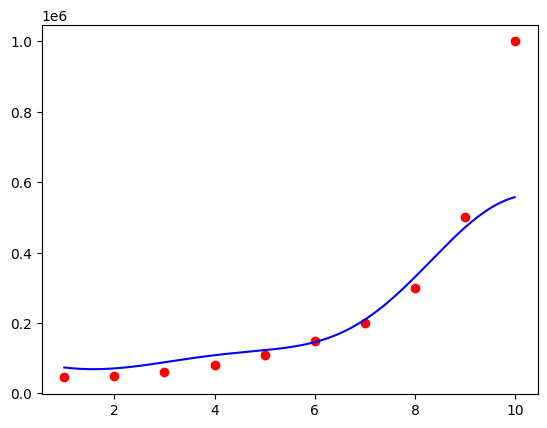

In [52]:
# smoothing the plot
X_grid = np.arange(min(sc_X.inverse_transform(X)), max(sc_X.inverse_transform(X)), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y.reshape(-1, 1)), color = 'red')
plt.plot(X_grid, sc_y.inverse_transform(model.predict(sc_X.transform(X_grid)).reshape(-1, 1)), color = 'blue')
plt.show()